# Plots de Matplotlib

El corazón de Matplotlib es la función `plot()`, la cual crea figuras con una o varias gráficas usando una configuración por defecto o una configuración especializada que nosotros le damos cuando invocamos la función. Estas gráficas se llaman "plots" dentro de Matplotlib y serán el centro de atención en esta lección. Empezaremos estudiando los conceptos básicos, incluyendo las dos formas disponibles para construir gráficas con esta librería. Al final de esta lección, veremos un ejemplo de una gráfica con ejes gemelos o "twins", en la cual se combinan dos series dentro del mismo espacio.

Empecemos con una gráfica realmente sencilla y basada en los datos históricos sobre temperaturas en Bogotá. En este caso, tenemos una lista llamada `meses`, en la cual tenemos los nombres abreviados de los 12 meses. También, tenemos una lista llamada `temperaturas_bog`, con 12 números flotantes.

## `plt.plot()`

Empecemos con una gráfica realmente sencilla y basada en los datos históricos sobre temperaturas en Bogotá. En este caso, tenemos una lista llamada `meses`, en la cual tenemos los nombres abreviados de los 12 meses. También, tenemos una lista llamada `temperaturas_bog`, con 12 números flotantes.

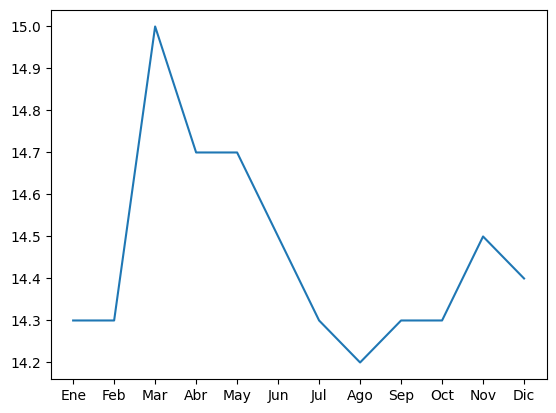

In [1]:
import matplotlib.pyplot as plt

meses: list[str] = [
    "Ene",
    "Feb",
    "Mar",
    "Abr",
    "May",
    "Jun",
    "Jul",
    "Ago",
    "Sep",
    "Oct",
    "Nov",
    "Dic"
]
temperaturas_bog: list[float] = [
    14.3,
    14.3,
    15.0,
    14.7,
    14.7,
    14.5,
    14.3,
    14.2,
    14.3,
    14.3,
    14.5,
    14.4
]

plt.plot(meses, temperaturas_bog)

Cuando llamamos a la función `plot()`, que está definida en el módulo que importamos con el alias `plt`, la función produce como resultado una figura como la de arriba.

Vemos que Matplotlib tomó varias decisiones interesantes por nosotros:
- Escogió un color para la serie y un ancho para la línea
- Ubicó los meses en el eje "x" e imprimió sus nombres
- Ubicó las temperaturas en el eje "y"
- Calculó en qué rangos se encontraban los valores para solo mostrar esa parte del eje
- Decidió cada cuánto poner una marca sobre el eje

Lo que haremos en el resto de esta lección será configurar Matplotlib para que las gráficas que construyamos sean claras y atractivas.

## Configuración básica

Jugando un poco con la configuración, tenemos la siguiente gráfica.

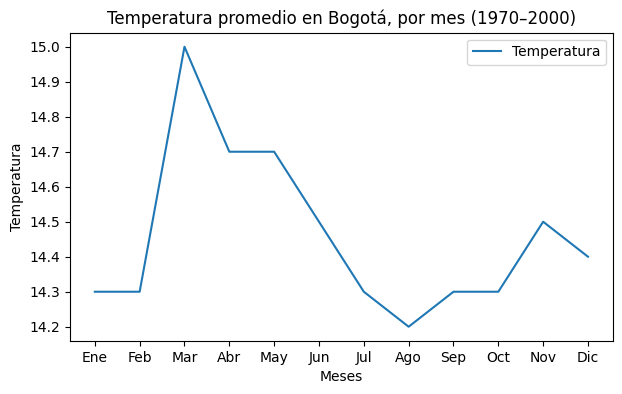

In [2]:
plt.figure(figsize=(7, 4))
plt.plot(meses, temperaturas_bog, label="Temperatura")
plt.xlabel("Meses")
plt.ylabel("Temperatura")
plt.title("Temperatura promedio en Bogotá, por mes (1970–2000)")
plt.legend()

En primer lugar, tenemos un llamado a la función `figure()`, la cual sirve para decirle a Matplotlib que vamos a construir una nueva figura. El parámetro `figsize` sirve para especificar el tamaño que queremos que tenga nuestra figura y, en este caso, es siete por cuatro.

Luego tenemos el llamado a la función `plot()`, la cual se encarga de calcular la visualización misma de la serie de datos. Esta vez, hemos agregado un parámetro nombrado adicional llamado `label`, el cual sirve para especificar qué nombre debe aparecer en la leyenda de la gráfica.

Las siguientes tres instrucciones invocan a las funciones `xlabel()`, `ylabel()` y `title()` y sirven para configurar las etiquetas de los ejes "x" y "y", así como el título de la gráfica.

Finalmente, tenemos una invocación a la función `legend()`, la cual sirve para pedirle a Matplotlib que incluya la leyenda dentro de la gráfica. Esta función puede recibir un parámetro adicional para fijar la ubicación de la leyenda, pero si no lo especificamos, Matplotlib buscará la mejor ubicación.

## Axes

Pasemos ahora a la segunda forma de construir gráficas con Matplotlib, que está basada en algo llamado "Axes". Esta forma es un poco más compleja que la anterior, pero es mucho más poderosa. De hecho, hay muchas características de la librería que no se pueden usar a menos que se utilice de esta manera.

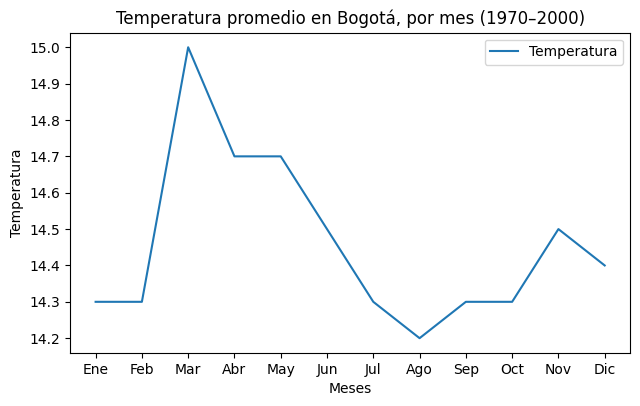

In [3]:
fig = plt.figure(figsize=(7, 4))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.plot(meses, temperaturas_bog, label="Temperatura")
ax.set_xlabel("Meses")
ax.set_ylabel("Temperatura")
ax.set_title("Temperatura promedio en Bogotá, por mes (1970–2000)")
ax.legend()

La primera diferencia con el caso anterior es que ahora estamos guardando el resultado de la invocación a `plt.figure()` en una variable llamada `fig`. Después, invocamos sobre `fig` el método `add_axes()`, que retorna algo de tipo "axes" que guardamos en la variable `ax`.

En Matplotlib, los "axes" son elementos que conforman las gráficas y son los responsables de las etiquetas, los ejes y los datos. Los "axes" no son equivalentes a los ejes y no tienen una buena traducción en español, así que es preferible usar el término en inglés siempre que sea necesario. Es por esto que en las siguientes instrucciones encontramos llamados similares a los que teníamos antes, pero ahora lo estamos haciendo sobre `ax`. Por ejemplo, la instrucción que antes decía `plt.ylabel()`, se convirtió en `ax.set_ylabel()`.

Finalmente, al haber almacenado la figura en la variable `fig`, se abre la posibilidad de hacer algo más con esta figura.

> Muchas veces, simplemente, invocaremos la función `show()` para visualizar la figura, pero también podemos usar la función `savefig()` para guardar la gráfica en un archivo.

### Parámetro de `add_axes()`

Ahora, estudiemos el parámetro de la función `add_axes()`, que tiene que ser una lista con cuatro números entre cero y uno. El primer número indica en qué posición estará el límite izquierdo del nuevo elemento respecto al ancho de la figura entera. Como en este caso el número era `0,1`, el borde del nuevo elemento `axe` se encuentra a un 10% de distancia de la izquierda. El segundo número es similar, pero se mide desde abajo. El tercer y cuarto números indican el ancho y el alto que debe tener el elemento con respecto al tamaño de la figura. En este caso, queríamos que el `axe` ocupara el 80% de la figura.

Se debe tener cuidado, ya que estos números no incluyen las etiquetas y se refieren únicamente al área donde se graficarán las series de datos. En este caso, se trata del rectángulo negro que vemos en la figura.

Si hubiéramos usado los valores `[0, 0, 1, 1]` para indicar que la esquina inferior izquierda del rectángulo debería coincidir con la esquina inferior izquierda de la figura, y que el rectángulo debería ocupar todo el ancho y todo el alto de la figura, habríamos terminado con un rectángulo, con la gráfica ocupando toda la figura. Pero los títulos y las etiquetas de los ejes habrían quedado por fuera y no los podríamos ver.

## Gráficas múltiples

Ahora veamos qué pasa si invocamos la función plot dos veces sobre el mismo `axe`.

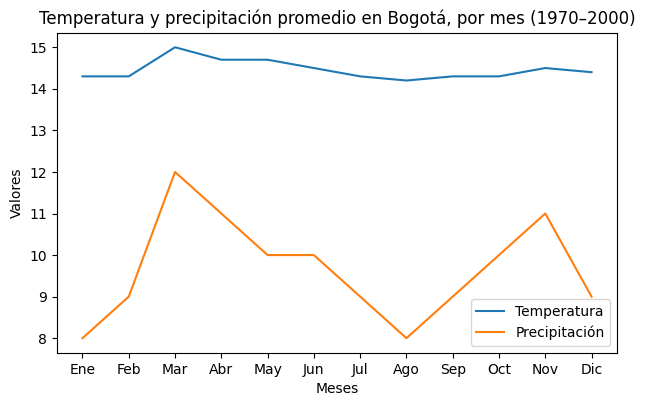

In [4]:
precipitacion_bog: list[float] = [
    8,
    9,
    12,
    11,
    10,
    10,
    9,
    8,
    9,
    10,
    11,
    9
]

fig = plt.figure(figsize=(7, 4))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.plot(meses, temperaturas_bog, label="Temperatura")
ax.plot(meses, precipitacion_bog, label="Precipitación")
ax.set_xlabel("Meses")
ax.set_ylabel("Valores")
ax.set_title("Temperatura y precipitación promedio en Bogotá, por mes (1970–2000)")
ax.legend()

En la imagen podemos ver el resultado. Matplotlib incluye dentro de la misma gráfica el nuevo set de datos usando un color diferente y hace los ajustes necesarios a los ejes para poder mostrar también esta información. Sin embargo, la gráfica que estamos viendo tiene un problema, las mediciones de temperatura y de precipitación tienen valores muy diferentes, así que las variaciones de temperatura casi no se pueden ver.

## Twins

Para solucionar este problema, necesitamos crear un segundo elemento, también de tipo `axes`.

Text(0, 0.5, 'Precipitación')

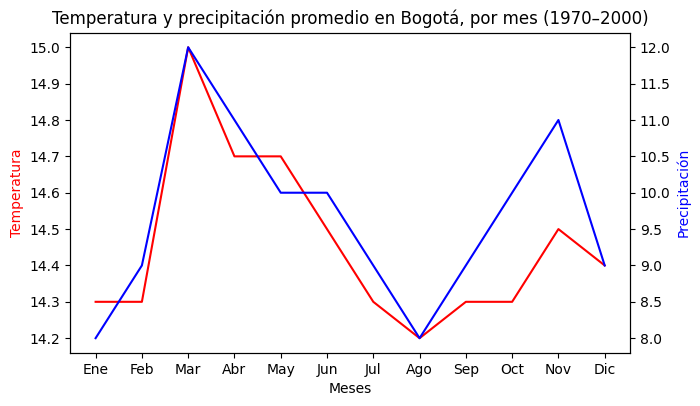

In [5]:
fig = plt.figure(figsize=(7, 4))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.plot(meses, temperaturas_bog, "r", label="Temperatura")
ax.set_xlabel("Meses")
ax.set_ylabel("Temperatura", color="red")
ax.set_title("Temperatura y precipitación promedio en Bogotá, por mes (1970–2000)")

ax2 = ax.twinx()
ax2.plot(meses, precipitacion_bog, "b", label="Precipitacion")
ax2.set_ylabel("Precipitación", color="blue")

En esta nueva imagen, podemos ver el resultado. En lugar de organizar la información de las dos series con base en el mismo eje de referencia, esta vez tenemos un eje para la temperatura y uno para la precipitación.

Para lograr esto, configuramos `ax`, como lo habíamos hecho la primera vez y luego creamos un gemelo usando la función `twinx()`.

El resultado lo guardamos en la variable `ax2` y sobre esta variable hicimos la invocación de la función `plot()`, con la información sobre precipitaciones. Además, en este ejemplo agregamos algunos parámetros adicionales para configurar los colores de las series y de las etiquetas. Esto lo estudiaremos con más detalle en una de las siguientes lecciones.

Para concluir, recordemos que en Matplotlib se pueden construir gráficas de línea usando simplemente la función `plot()`. Sin embargo, podremos armar gráficas muchísimo más interesantes y atractivas, si utilizamos figuras y `axes`.